# Customer Segmentation & Churn Pattern Analytics in European Banking

## Notebook 06

### Model Explainability & Business Insights

### Objective

This notebook explains how the trained Gradient Boosting model makes churn predictions.

The notebook includes:

- Feature importance analysis
- Permutation importance
- SHAP explainability
- Customer risk segmentation
- Business insights
- Strategic banking recommendations

These analyses improve model transparency and support business decision-making.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.inspection import permutation_importance

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
current_directory = Path.cwd()

if current_directory.name.lower() == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

data_directory = project_root / "data"
processed_directory = data_directory / "processed"

model_directory = project_root / "models"

output_directory = project_root / "outputs"

table_directory = output_directory / "tables"

chart_directory = output_directory / "charts"

for folder in [
    processed_directory,
    model_directory,
    table_directory,
    chart_directory
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print(project_root)

d:\Customer_Segmentation_Churn_Banking


In [3]:
model_path = (
    model_directory /
    "final_smote_gradient_boosting.pkl"
)

model = joblib.load(
    model_path
)

print("Final model loaded successfully.")

Final model loaded successfully.


In [4]:
X_test = pd.read_csv(
    processed_directory /
    "X_test.csv"
)

y_test = (
    pd.read_csv(
        processed_directory /
        "y_test.csv"
    )
    .squeeze()
)

prediction_df = pd.read_csv(
    processed_directory /
    "final_test_predictions.csv"
)

print("Datasets loaded.")

Datasets loaded.


In [5]:
print("="*65)
print("MODEL EXPLAINABILITY DATASET")
print("="*65)

print(f"Test Features : {X_test.shape}")
print(f"Test Target   : {y_test.shape}")

print(
    f"Prediction File : "
    f"{prediction_df.shape}"
)

print(
    f"Missing Values : "
    f"{X_test.isna().sum().sum()}"
)

print(
    f"Features : "
    f"{len(X_test.columns)}"
)

MODEL EXPLAINABILITY DATASET
Test Features : (2000, 17)
Test Target   : (2000,)
Prediction File : (2000, 4)
Missing Values : 0
Features : 17


In [6]:
prediction_df[
    "Churn_Probability"
] = model.predict_proba(
    X_test
)[:,1]

prediction_df.head()

,Actual_Exited,Churn_Probability,Predicted_Exited,Prediction_Status
0,0,0.051137,0,Predicted Retained
1,0,0.197260,0,Predicted Retained
2,0,0.169798,0,Predicted Retained
3,0,0.113600,0,Predicted Retained
4,0,0.236320,0,Predicted Retained


In [7]:
def risk_level(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.56:
        return "Medium Risk"

    elif probability < 0.75:
        return "High Risk"

    else:
        return "Critical Risk"


prediction_df[
    "Risk_Level"
] = prediction_df[
    "Churn_Probability"
].apply(
    risk_level
)

prediction_df.head()

,Actual_Exited,Churn_Probability,Predicted_Exited,Prediction_Status,Risk_Level
0,0,0.051137,0,Predicted Retained,Low Risk
1,0,0.197260,0,Predicted Retained,Low Risk
2,0,0.169798,0,Predicted Retained,Low Risk
3,0,0.113600,0,Predicted Retained,Low Risk
4,0,0.236320,0,Predicted Retained,Low Risk


In [ ]:
risk_summary = (
    prediction_df[
        "Risk_Level"
    ]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "Risk_Level",
    "Customers"
]

risk_summary[
    "Percentage"
] = (
    risk_summary[
        "Customers"
    ]/
    len(prediction_df)
    *100
).round(2)

risk_summary

,Risk_Level,Customers,Percentage
0,Low Risk,1043,52.15
1,Medium Risk,499,24.95
2,Critical Risk,247,12.35
3,High Risk,211,10.55


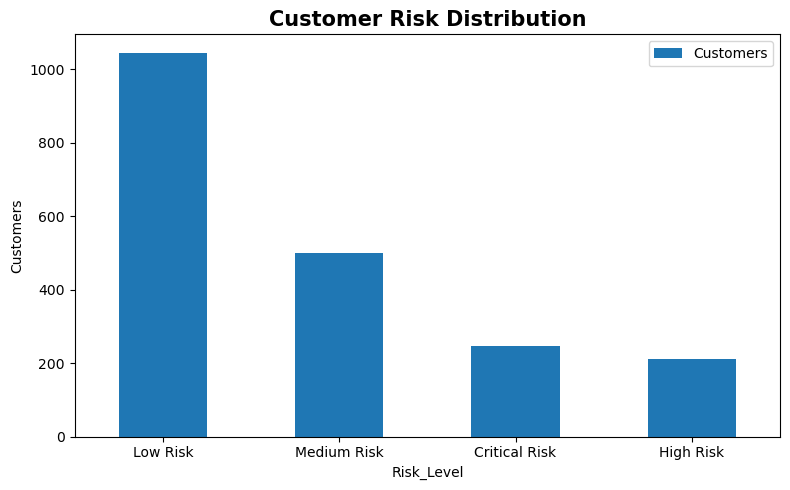

In [9]:
ax = risk_summary.plot(
    x="Risk_Level",
    y="Customers",
    kind="bar",
    figsize=(8,5)
)

ax.set_title(
    "Customer Risk Distribution",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel(
    "Customers"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    chart_directory /
    "50_customer_risk_distribution.png",
    dpi=300
)

plt.show()

In [10]:
feature_importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance":
    model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,Age,0.469084
1,NumOfProducts,0.189811
2,ProductEngagementScore,0.105162
3,Gender_Male,0.050412
4,Tenure,0.033705
5,CustomerValueScore,0.033201
6,Geography_Germany,0.020105
7,Geography_Spain,0.019527
8,Balance,0.019320
9,IsActiveMember,0.016995


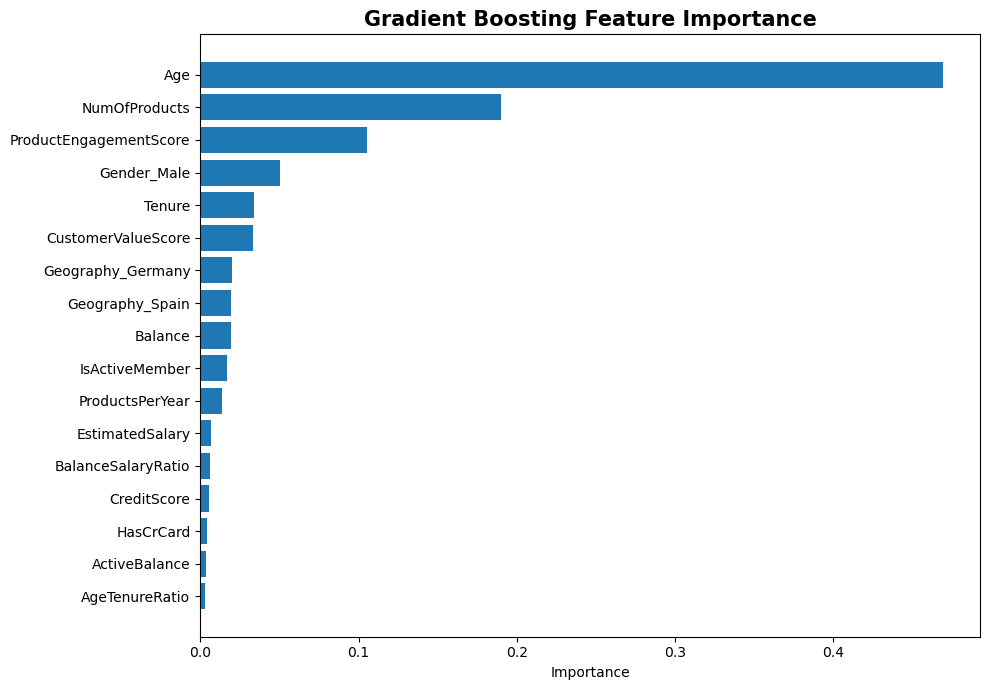

In [11]:
plt.figure(figsize=(10,7))

plt.barh(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title(
    "Gradient Boosting Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    chart_directory /
    "51_feature_importance.png",
    dpi=300
)

plt.show()

In [12]:
top10_features = feature_importance.head(10)

top10_features

,Feature,Importance
0,Age,0.469084
1,NumOfProducts,0.189811
2,ProductEngagementScore,0.105162
3,Gender_Male,0.050412
4,Tenure,0.033705
5,CustomerValueScore,0.033201
6,Geography_Germany,0.020105
7,Geography_Spain,0.019527
8,Balance,0.019320
9,IsActiveMember,0.016995


In [13]:
top10_features.to_csv(

    table_directory /

    "top10_feature_importance.csv",

    index=False

)

print("Top 10 feature importance saved.")

Top 10 feature importance saved.


In [14]:
perm_importance = permutation_importance(

    model,

    X_test,

    y_test,

    n_repeats=10,

    random_state=42,

    scoring="f1"

)

In [15]:
permutation_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance":
    perm_importance.importances_mean

})

permutation_df = (
    permutation_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df

,Feature,Importance
0,Age,0.170735
1,NumOfProducts,0.084859
2,ProductEngagementScore,0.038333
3,Gender_Male,0.013908
4,CustomerValueScore,0.013387
5,IsActiveMember,0.009447
6,Geography_Germany,0.005755
7,Geography_Spain,0.003015
8,ProductsPerYear,0.002350
9,AgeTenureRatio,0.002272


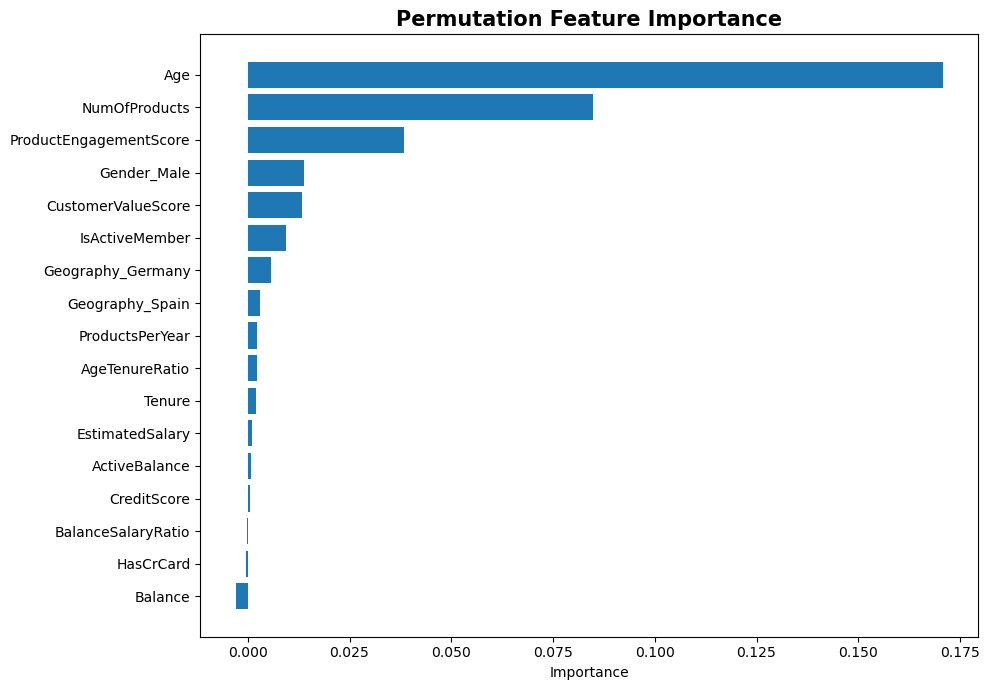

In [16]:
plt.figure(figsize=(10,7))

plt.barh(

    permutation_df["Feature"],

    permutation_df["Importance"]

)

plt.gca().invert_yaxis()

plt.title(

    "Permutation Feature Importance",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(

    chart_directory /

    "52_permutation_importance.png",

    dpi=300

)

plt.show()

In [18]:
try:
    import shap

    print("="*65)
    print("SHAP STATUS")
    print("="*65)

    print("SHAP version :", shap.__version__)
    print("SHAP is installed successfully.")

except ImportError:

    print("SHAP is NOT installed.")
    print("Run:")
    print("pip install shap")

SHAP STATUS
SHAP version : 0.52.0
SHAP is installed successfully.


In [19]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")

SHAP values generated successfully.


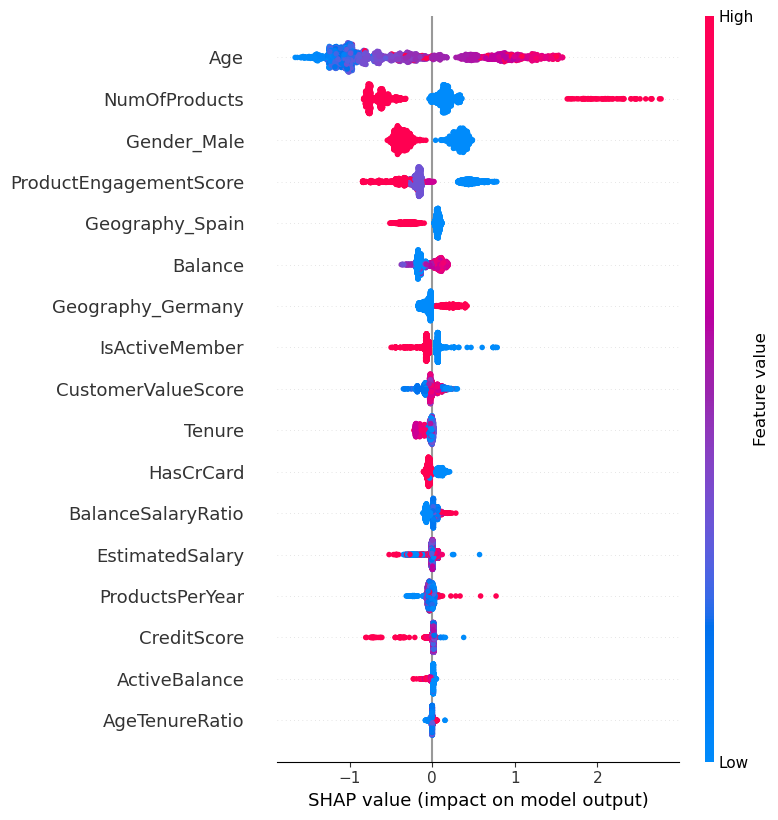

In [20]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    chart_directory /
    "53_shap_summary.png",
    dpi=300
)

plt.show()

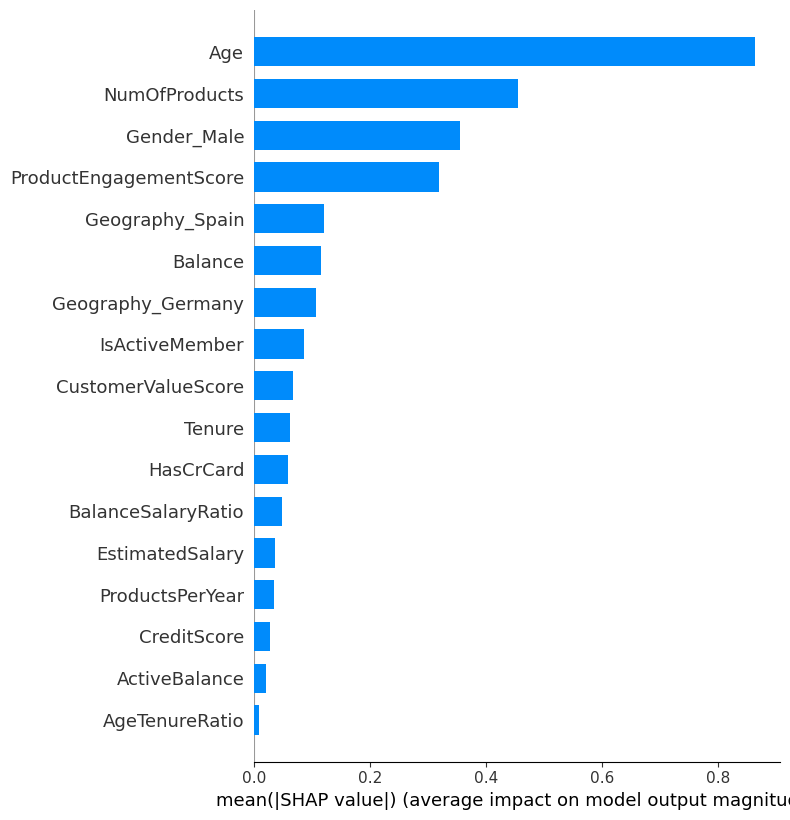

In [21]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    chart_directory /
    "54_shap_bar.png",
    dpi=300
)

plt.show()

In [22]:
high_risk_customers = prediction_df[
    prediction_df["Risk_Level"].isin(
        [
            "High Risk",
            "Critical Risk"
        ]
    )
].copy()

print("="*65)
print("HIGH RISK CUSTOMERS")
print("="*65)

print(
    f"Customers : {len(high_risk_customers)}"
)

print(
    f"Percentage : "
    f"{len(high_risk_customers)/len(prediction_df)*100:.2f}%"
)

high_risk_customers.head()

HIGH RISK CUSTOMERS
Customers : 458
Percentage : 22.90%


,Actual_Exited,Churn_Probability,Predicted_Exited,Prediction_Status,Risk_Level
8,0,0.802063,1,Predicted Churn,Critical Risk
10,1,0.844188,1,Predicted Churn,Critical Risk
11,0,0.628650,1,Predicted Churn,High Risk
18,1,0.860465,1,Predicted Churn,Critical Risk
19,0,0.619635,1,Predicted Churn,High Risk


In [23]:
low_risk_customers = prediction_df[
    prediction_df["Risk_Level"]=="Low Risk"
].copy()

print("="*65)
print("LOW RISK CUSTOMERS")
print("="*65)

print(
    f"Customers : {len(low_risk_customers)}"
)

print(
    f"Percentage : "
    f"{len(low_risk_customers)/len(prediction_df)*100:.2f}%"
)

low_risk_customers.head()

LOW RISK CUSTOMERS
Customers : 1043
Percentage : 52.15%


,Actual_Exited,Churn_Probability,Predicted_Exited,Prediction_Status,Risk_Level
0,0,0.051137,0,Predicted Retained,Low Risk
1,0,0.197260,0,Predicted Retained,Low Risk
2,0,0.169798,0,Predicted Retained,Low Risk
3,0,0.113600,0,Predicted Retained,Low Risk
4,0,0.236320,0,Predicted Retained,Low Risk


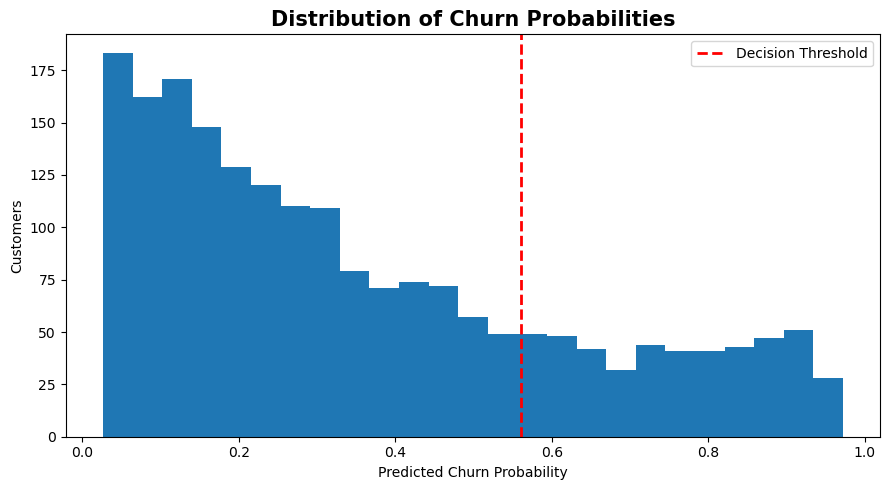

In [24]:
plt.figure(figsize=(9,5))

plt.hist(
    prediction_df["Churn_Probability"],
    bins=25
)

plt.axvline(
    0.56,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision Threshold"
)

plt.title(
    "Distribution of Churn Probabilities",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Churn Probability"
)

plt.ylabel(
    "Customers"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    chart_directory /
    "55_probability_distribution.png",
    dpi=300
)

plt.show()

In [25]:
business_insights = [

    "Age is the strongest predictor of customer churn.",

    "Customers with fewer banking products are significantly more likely to churn.",

    "Lower engagement strongly increases churn probability.",

    "Germany exhibits higher churn risk than France and Spain.",

    "Inactive customers have considerably higher churn rates.",

    "Older customers contribute disproportionately to churn risk.",

    "Customer value and tenure influence churn but are less important than engagement and age."

]

for i, insight in enumerate(
    business_insights,
    start=1
):
    print(f"{i}. {insight}")

1. Age is the strongest predictor of customer churn.
2. Customers with fewer banking products are significantly more likely to churn.
3. Lower engagement strongly increases churn probability.
4. Germany exhibits higher churn risk than France and Spain.
5. Inactive customers have considerably higher churn rates.
6. Older customers contribute disproportionately to churn risk.
7. Customer value and tenure influence churn but are less important than engagement and age.


In [26]:
recommendations = [

    "Prioritize proactive retention campaigns for high-risk customers.",

    "Increase engagement initiatives for inactive customers.",

    "Promote cross-selling to customers with only one banking product.",

    "Develop targeted retention strategies for customers in Germany.",

    "Introduce loyalty benefits for older high-value customers.",

    "Monitor customers whose churn probability exceeds 56%.",

    "Deploy the trained Gradient Boosting model within customer relationship management systems."

]

for i, recommendation in enumerate(
    recommendations,
    start=1
):
    print(f"{i}. {recommendation}")

1. Prioritize proactive retention campaigns for high-risk customers.
2. Increase engagement initiatives for inactive customers.
3. Promote cross-selling to customers with only one banking product.
4. Develop targeted retention strategies for customers in Germany.
5. Introduce loyalty benefits for older high-value customers.
6. Monitor customers whose churn probability exceeds 56%.
7. Deploy the trained Gradient Boosting model within customer relationship management systems.


In [27]:
feature_importance.to_csv(
    table_directory /
    "feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    table_directory /
    "permutation_importance.csv",
    index=False
)

risk_summary.to_csv(
    table_directory /
    "customer_risk_summary.csv",
    index=False
)

print("Explainability tables saved.")

Explainability tables saved.


In [28]:
print("="*70)
print("NOTEBOOK 06 VERIFICATION")
print("="*70)

print(
    f"Feature Importance : "
    f"{len(feature_importance)} features"
)

print(
    f"Permutation Importance : "
    f"{len(permutation_df)} features"
)

print(
    f"Risk Categories : "
    f"{len(risk_summary)}"
)

print(
    f"High Risk Customers : "
    f"{len(high_risk_customers)}"
)

print(
    f"Low Risk Customers : "
    f"{len(low_risk_customers)}"
)

print("\nNotebook 06 completed successfully.")

NOTEBOOK 06 VERIFICATION
Feature Importance : 17 features
Permutation Importance : 17 features
Risk Categories : 4
High Risk Customers : 458
Low Risk Customers : 1043

Notebook 06 completed successfully.
